In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

In [5]:
# 1. Load and Clean Data
DATA_DIR = "../data/kaggle_3m"
df = pd.read_csv(os.path.join(DATA_DIR, 'data.csv'))
df.columns = df.columns.str.strip() 

In [14]:
# 2. Data Overview & Health Check
print("\nFirst 3 rows of CSV:")
display(df.head(3))
print("Data Overview:")
df.info()
print("\nMissing Values per Column:")
print(df.isnull().sum())


First 3 rows of CSV:


,Patient,RNASeqCluster,MethylationCluster,miRNACluster,CNCluster,RPPACluster,OncosignCluster,COCCluster,histological_type,neoplasm_histologic_grade,tumor_tissue_site,laterality,tumor_location,gender,age_at_initial_pathologic,race,ethnicity,death01
0,TCGA_CS_4941,2.0,4.0,2,2.0,NaN,3.0,2,1.0,2.0,1.0,3.0,2.0,2.0,67.0,3.0,2.0,1.0
1,TCGA_CS_4942,1.0,5.0,2,1.0,1.0,2.0,1,1.0,2.0,1.0,3.0,2.0,1.0,44.0,2.0,NaN,1.0
2,TCGA_CS_4943,1.0,5.0,2,1.0,2.0,2.0,1,1.0,2.0,1.0,1.0,2.0,2.0,37.0,3.0,NaN,0.0


Data Overview:
<class 'pandas.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Patient                    110 non-null    str    
 1   RNASeqCluster              92 non-null     float64
 2   MethylationCluster         109 non-null    float64
 3   miRNACluster               110 non-null    int64  
 4   CNCluster                  108 non-null    float64
 5   RPPACluster                98 non-null     float64
 6   OncosignCluster            105 non-null    float64
 7   COCCluster                 110 non-null    int64  
 8   histological_type          109 non-null    float64
 9   neoplasm_histologic_grade  109 non-null    float64
 10  tumor_tissue_site          109 non-null    float64
 11  laterality                 109 non-null    float64
 12  tumor_location             109 non-null    float64
 13  gender                     109 non-null    flo

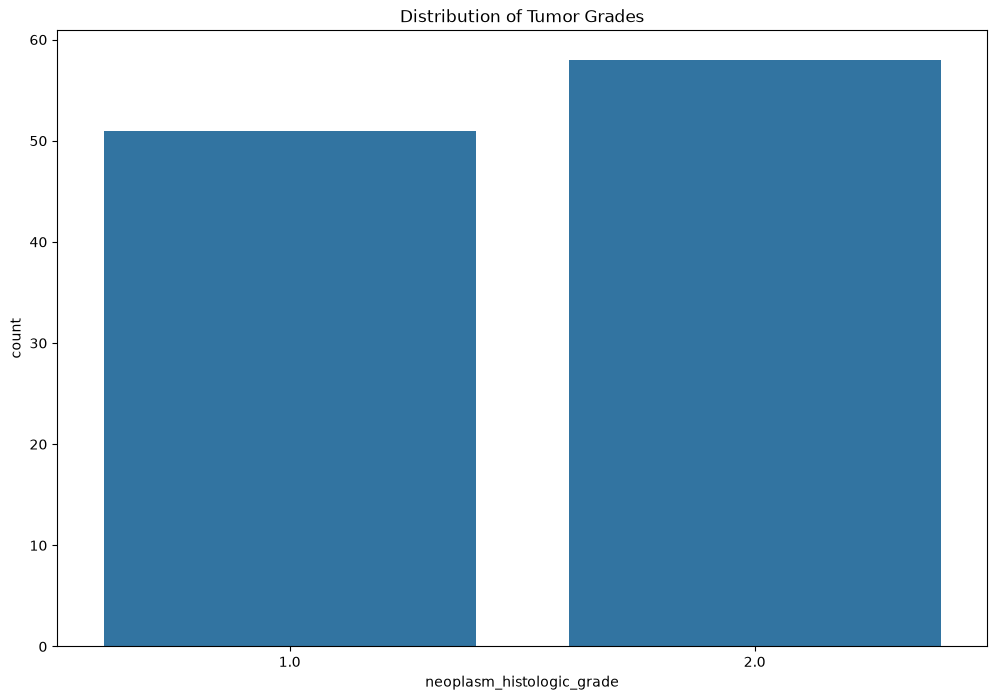

In [8]:
# 3. Univariate Analysis
plt.figure(figsize=(12, 8))
sns.countplot(x='neoplasm_histologic_grade', data=df)
plt.title('Distribution of Tumor Grades')
plt.show()

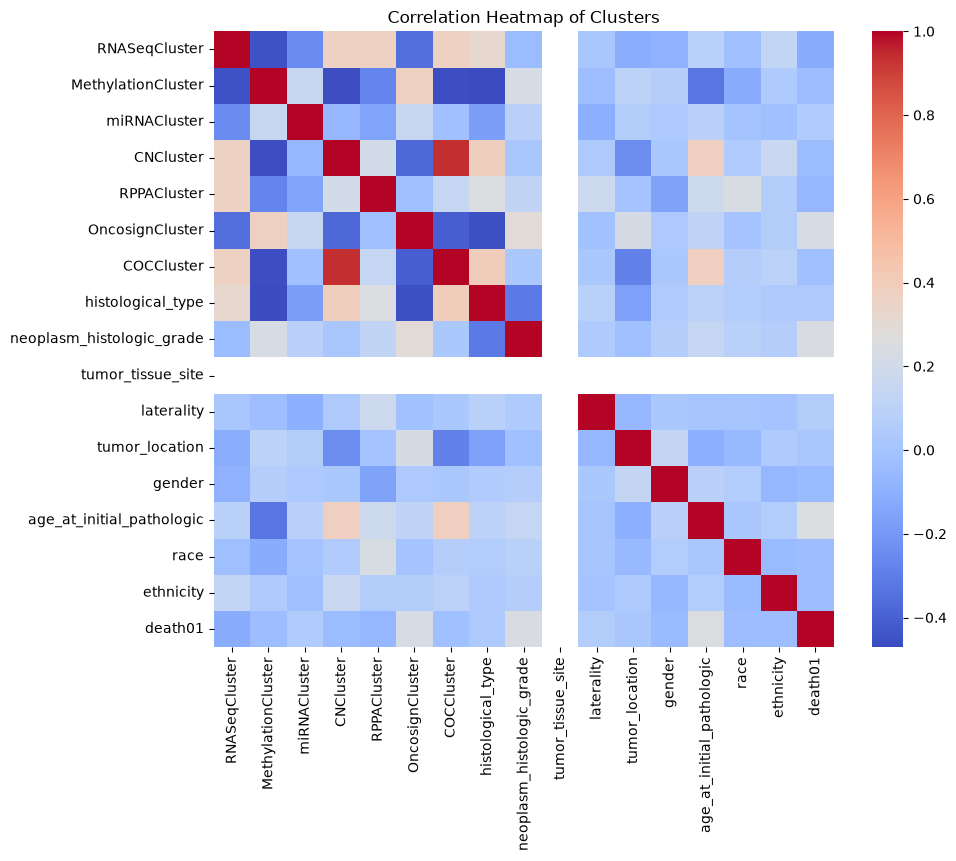

In [15]:
# 4. Correlation Analysis
numeric_df = df.drop(columns=['Patient'])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap of Clusters')
plt.show()

In [18]:
# 5. Image-Metadata Linkage
def show_sample(patient_id):
    """
    patient_id: The identifier from the CSV (e.g., 'TCGA_CS_4941')
    """
    search_path = os.path.join(DATA_DIR, '**', f"{patient_id}*.tif")
    image_files = glob.glob(search_path, recursive=True)
    
    if not image_files:
        print(f"Error: Could not find file for {patient_id}")
        return
    
    img = plt.imread(image_files[0])
    plt.imshow(img, cmap='gray')
    plt.title(f"Patient: {patient_id}")
    plt.show()

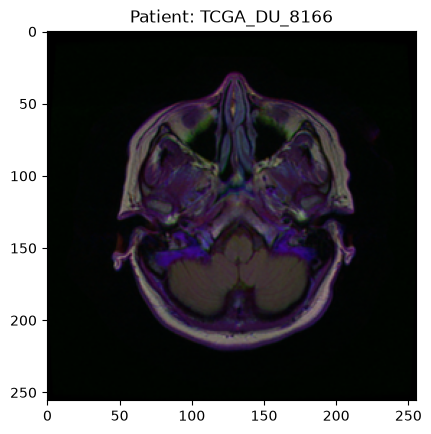

In [19]:
# Show a random sample
random_patient = df['Patient'].dropna().sample(1).values[0]
show_sample(random_patient)